# Credit Approval Model — Analysis & Experiments

Este proyecto implementa un modelo de *Machine Learning* para predecir la categoría de aprobación de crédito (**Approved_Flag**) utilizando variables financieras y comportamentales.

Se desarrollan dos escenarios experimentales:

1. **With Credit_Score** (escenario real del negocio)
2. **Without Credit_Score** (ablation study para analizar dependencia estructural)

El objetivo principal es evaluar el impacto del **Credit_Score** en la decisión final y medir la capacidad predictiva del resto de las variables cuando dicha información no está disponible.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from src.pipeline import build_model_pipeline
from src.config import (
    CASE_STUDY_1_PATH,
    CASE_STUDY_2_PATH,
    ID_COL,
    TARGET_COL,
    MISSING_VALUE_SENTINEL,
    RANDOM_SEED,
    TEST_SIZE,
    CREDIT_SCORE_COL,
)

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 140

In [2]:
def load_and_merge() -> pd.DataFrame:
    df1 = pd.read_excel(CASE_STUDY_1_PATH)
    df2 = pd.read_excel(CASE_STUDY_2_PATH)
    df = df2.merge(df1, on=ID_COL, how="inner")
    df = df.replace(MISSING_VALUE_SENTINEL, np.nan)
    df = df[df[TARGET_COL].notna()].copy()
    return df

df = load_and_merge()
df.shape, df.columns[:10]

((51336, 87),
 Index(['PROSPECTID', 'time_since_recent_payment',
        'time_since_first_deliquency', 'time_since_recent_deliquency',
        'num_times_delinquent', 'max_delinquency_level',
        'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
        'num_deliq_6_12mts'],
       dtype='str'))

In [3]:
print("Rows:", len(df))
print("Target distribution:")
print(df[TARGET_COL].value_counts(dropna=False))

Rows: 51336
Target distribution:
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64


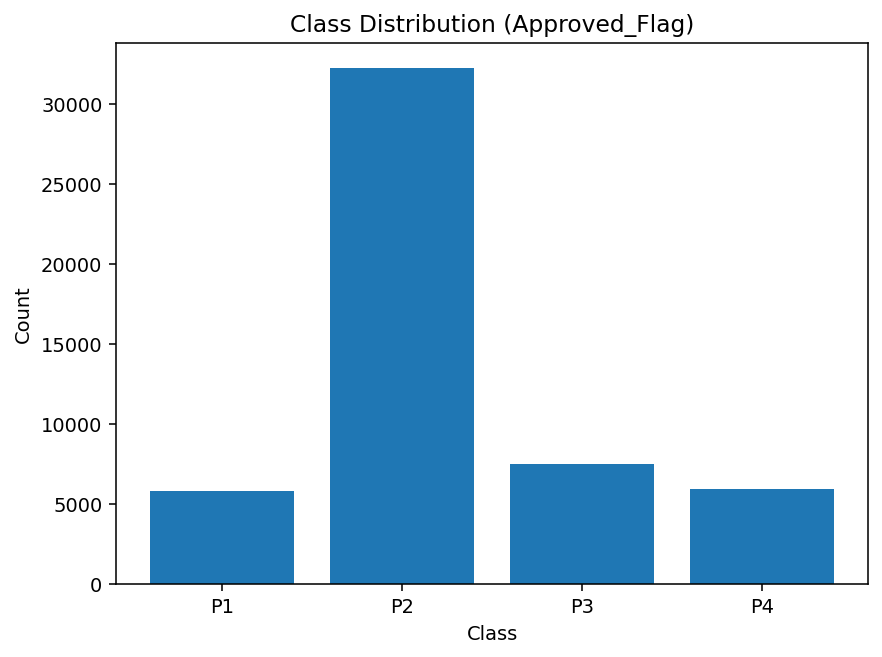

WindowsPath('c:/Users/Usuario/OneDrive/Escritorio/PROYECTOS/Data/credit-risk-classification-ml/reports/figures/class_distribution.png')

In [4]:
counts = df[TARGET_COL].value_counts().sort_index()

fig = plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution (Approved_Flag)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()

out = FIG_DIR / "class_distribution.png"
plt.savefig(out)
plt.show()

out

In [5]:
def plot_confusion_matrix(cm: np.ndarray, labels: list[str], title: str, filename: str) -> None:
    fig = plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=0)
    plt.yticks(tick_marks, labels)

    thresh = cm.max() * 0.6 if cm.max() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            plt.text(j, i, str(val), ha="center", va="center",
                     color="white" if val > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    out = FIG_DIR / filename
    plt.savefig(out)
    plt.show()


def get_feature_names(pipe, X_train: pd.DataFrame) -> list[str]:
    preprocess = pipe.named_steps["preprocess"]
    num_cols = preprocess.transformers_[0][2]
    cat_cols = preprocess.transformers_[1][2]

    names = [str(c) for c in num_cols]

    cat_pipeline = preprocess.named_transformers_["cat"]
    ohe = cat_pipeline.named_steps["onehot"]
    ohe_names = ohe.get_feature_names_out(cat_cols)
    names.extend([str(n) for n in ohe_names])

    return names


def top_feature_importance(pipe, X_train: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    model = pipe.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        return pd.DataFrame(columns=["feature", "importance"])

    names = get_feature_names(pipe, X_train)
    importances = model.feature_importances_
    n = min(len(names), len(importances))

    df_imp = pd.DataFrame({"feature": names[:n], "importance": importances[:n]})
    df_imp = df_imp.sort_values("importance", ascending=False).head(top_n).reset_index(drop=True)
    return df_imp

In [6]:
def run_experiment(drop_credit_score: bool):
    y = df[TARGET_COL]
    X = df.drop(columns=[TARGET_COL])

    if ID_COL in X.columns:
        X = X.drop(columns=[ID_COL])

    if drop_credit_score and CREDIT_SCORE_COL in X.columns:
        X = X.drop(columns=[CREDIT_SCORE_COL])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
    )

    pipe = build_model_pipeline(X_train, RANDOM_SEED)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    labels = sorted([str(x) for x in y.unique()])
    cm = confusion_matrix(y_test.astype(str), y_pred.astype(str), labels=labels)

    report = classification_report(y_test, y_pred, zero_division=0)

    imp = top_feature_importance(pipe, X_train, top_n=15)

    return {
        "acc": acc,
        "labels": labels,
        "cm": cm,
        "report": report,
        "importance": imp,
    }

In [7]:
res_with = run_experiment(drop_credit_score=False)
res_wo = run_experiment(drop_credit_score=True)

res_with["acc"], res_wo["acc"]

(0.9953252824308532, 0.6931242695753799)

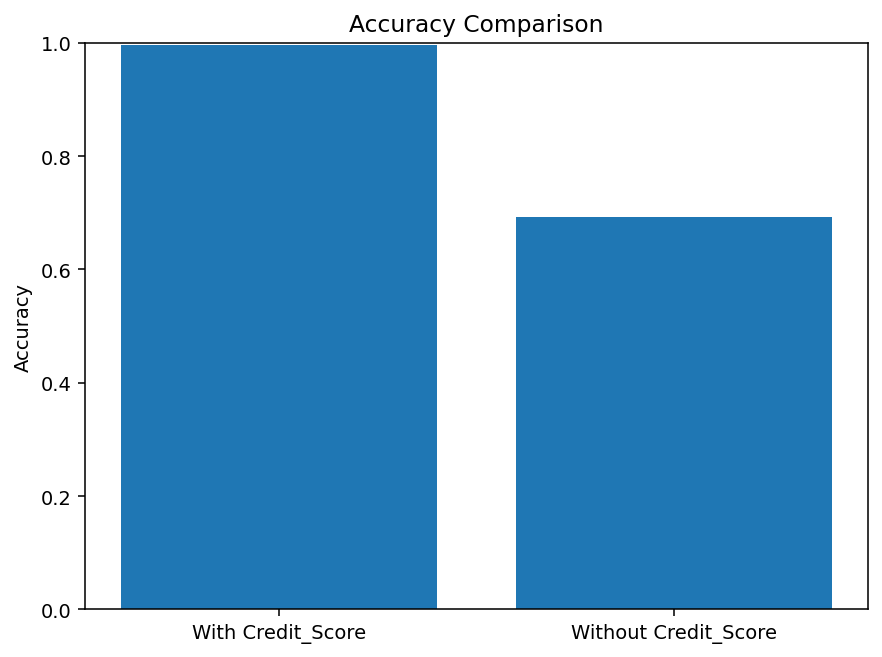

WindowsPath('c:/Users/Usuario/OneDrive/Escritorio/PROYECTOS/Data/credit-risk-classification-ml/reports/figures/accuracy_comparison.png')

In [8]:
fig = plt.figure()
plt.bar(["With Credit_Score", "Without Credit_Score"], [res_with["acc"], res_wo["acc"]])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()

out = FIG_DIR / "accuracy_comparison.png"
plt.savefig(out)
plt.show()

out

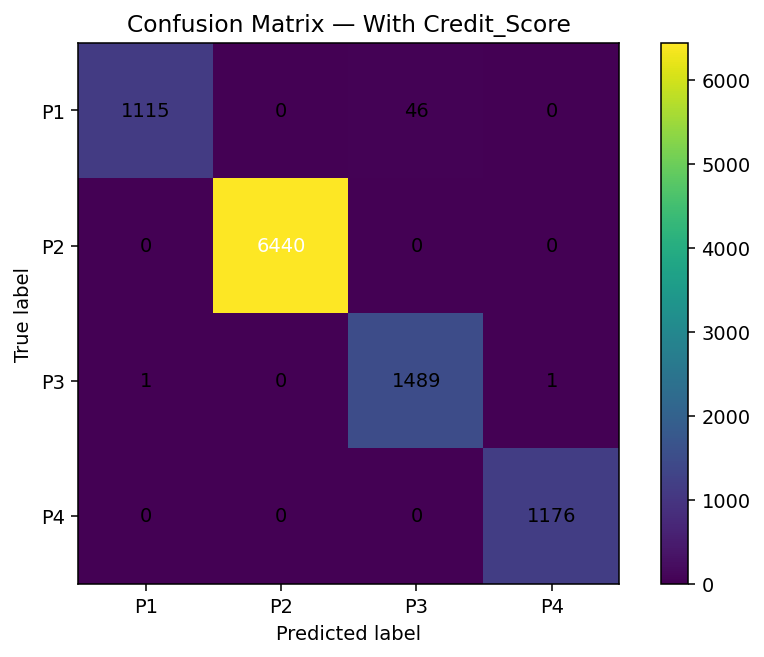

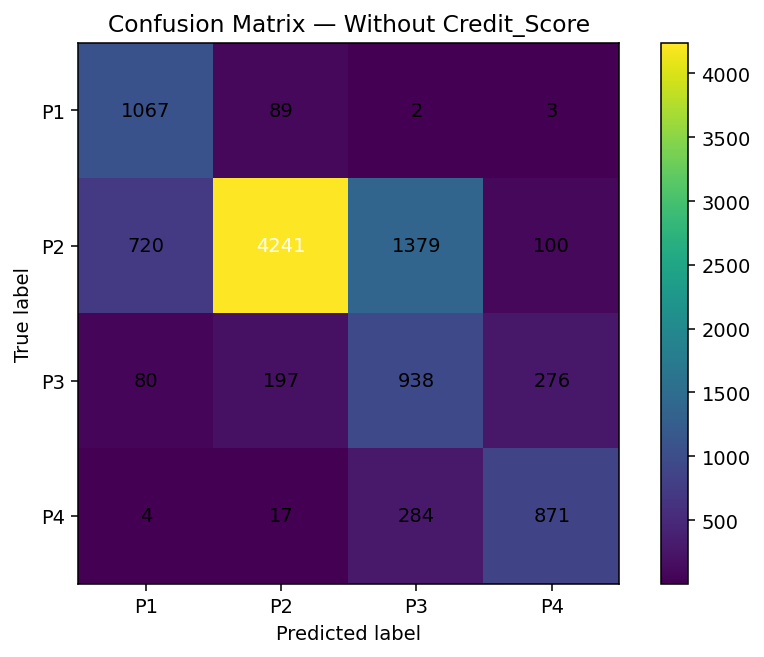

In [9]:
plot_confusion_matrix(
    res_with["cm"],
    res_with["labels"],
    "Confusion Matrix — With Credit_Score",
    "confusion_with_credit_score.png",
)

plot_confusion_matrix(
    res_wo["cm"],
    res_wo["labels"],
    "Confusion Matrix — Without Credit_Score",
    "confusion_without_credit_score.png",
)

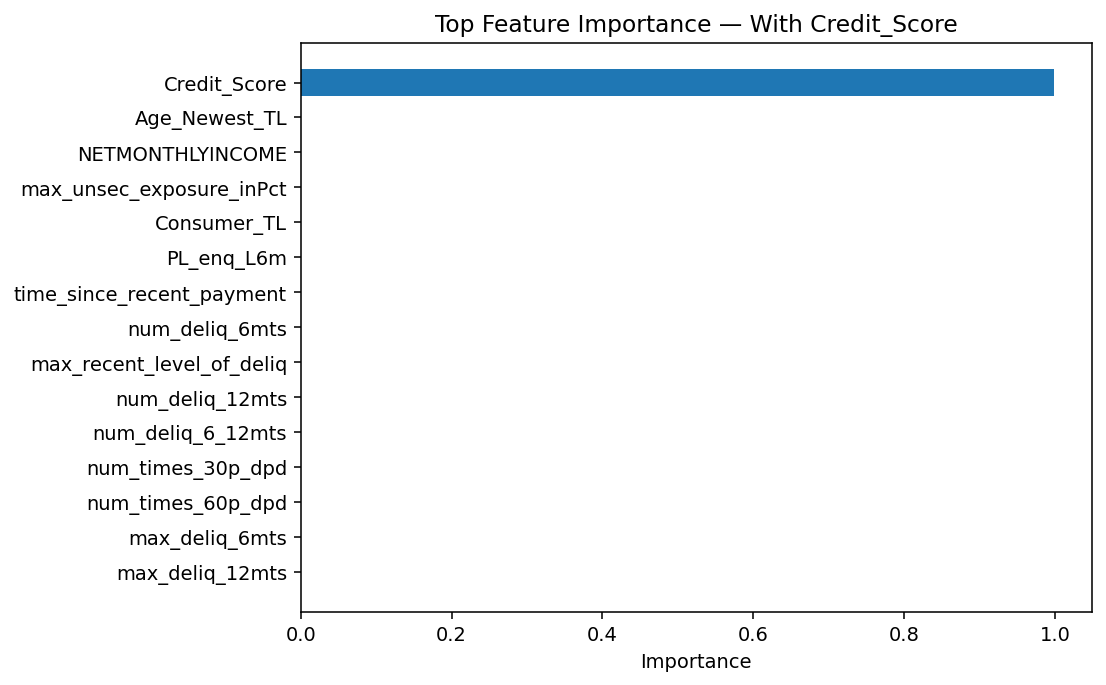

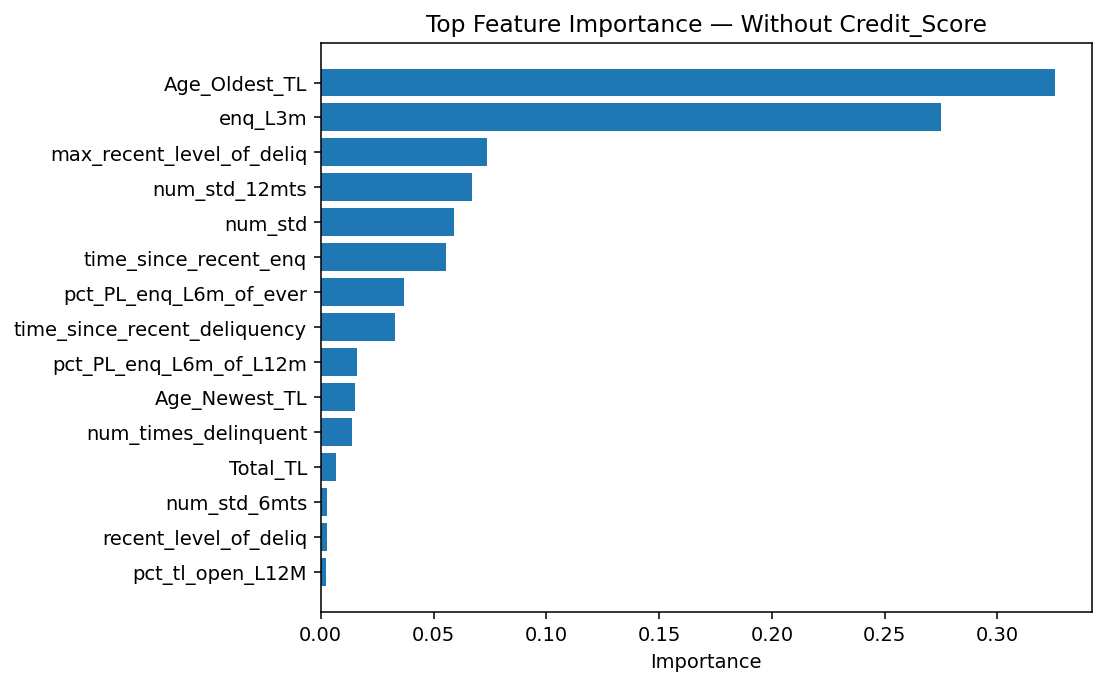

In [10]:
def plot_importance(df_imp: pd.DataFrame, title: str, filename: str) -> None:
    fig = plt.figure(figsize=(8, 5))
    d = df_imp.iloc[::-1]
    plt.barh(d["feature"].astype(str), d["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    out = FIG_DIR / filename
    plt.savefig(out)
    plt.show()

plot_importance(
    res_with["importance"],
    "Top Feature Importance — With Credit_Score",
    "importance_with_credit_score.png",
)

plot_importance(
    res_wo["importance"],
    "Top Feature Importance — Without Credit_Score",
    "importance_without_credit_score.png",
)

## Key Insight & Conclusion

El modelo con Credit_Score alcanza una precisión cercana al 99%, indicando que el sistema de aprobación depende fuertemente de esta variable.

Al eliminar el Credit_Score, la precisión cae aproximadamente 30 puntos porcentuales (~69%), lo que confirma su rol dominante en el proceso de decisión.

Conclusión: el sistema está estructuralmente condicionado por el score crediticio, aunque existen señales predictivas adicionales en el comportamiento financiero.

In [11]:
(PROJECT_ROOT / "reports" / "notebook_report_with_score.txt").write_text(res_with["report"], encoding="utf-8")
(PROJECT_ROOT / "reports" / "notebook_report_without_score.txt").write_text(res_wo["report"], encoding="utf-8")
print("Saved notebook reports to reports/notebook_report_*.txt")

Saved notebook reports to reports/notebook_report_*.txt
